In [23]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

tickers = [
    "AOT.BK","PTT.BK","CPALL.BK","SCB.BK","KBANK.BK",
    "BBL.BK","KTB.BK","SCC.BK","ADVANC.BK","TRUE.BK",
    "BH.BK","BDMS.BK","CPN.BK","LH.BK","MINT.BK",
    "TOP.BK","PTTEP.BK","HMPRO.BK","OSP.BK","GPSC.BK",
    "BGRIM.BK","RATCH.BK","TTB.BK","KKP.BK","GULF.BK"
]

print("กำลังดึงข้อมูลราคา...")

# ดึงแบบทีละตัว แล้วเลือก Close จาก MultiIndex
price_dict = {}
for ticker in tickers:
    try:
        df = yf.download(ticker, start="2019-01-01",
                         end="2026-01-01",
                         auto_adjust=True, progress=False)
        # Column เป็น MultiIndex → ('Close', 'AOT.BK')
        close = df[('Close', ticker)]
        if len(close) > 100:
            price_dict[ticker] = close
            print(f"  ✅ {ticker}: {len(close)} วัน")
        else:
            print(f"  ⚠️ {ticker}: น้อยเกินไป")
    except Exception as e:
        print(f"  ❌ {ticker}: {e}")


prices  = pd.DataFrame(price_dict)
prices  = prices.dropna(thresh=int(len(prices.columns)*0.8))  # ต้องมีข้อมูลอย่างน้อย 80% ของหุ้น
returns = prices.pct_change().dropna(thresh=int(len(prices.columns)*0.8))

print(f"\n✅ Shape: {returns.shape}")
print(f"   {returns.index[0].date()} → {returns.index[-1].date()}")

กำลังดึงข้อมูลราคา...
  ✅ AOT.BK: 1697 วัน
  ✅ PTT.BK: 1697 วัน
  ✅ CPALL.BK: 1697 วัน
  ✅ SCB.BK: 894 วัน
  ✅ KBANK.BK: 1697 วัน
  ✅ BBL.BK: 1697 วัน
  ✅ KTB.BK: 1697 วัน
  ✅ SCC.BK: 1697 วัน
  ✅ ADVANC.BK: 1697 วัน
  ✅ TRUE.BK: 1697 วัน
  ✅ BH.BK: 1697 วัน
  ✅ BDMS.BK: 1697 วัน
  ✅ CPN.BK: 1697 วัน
  ✅ LH.BK: 1697 วัน
  ✅ MINT.BK: 1697 วัน
  ✅ TOP.BK: 1697 วัน
  ✅ PTTEP.BK: 1697 วัน
  ✅ HMPRO.BK: 1697 วัน
  ✅ OSP.BK: 1697 วัน
  ✅ GPSC.BK: 1697 วัน
  ✅ BGRIM.BK: 1697 วัน
  ✅ RATCH.BK: 1697 วัน
  ✅ TTB.BK: 1697 วัน
  ✅ KKP.BK: 1697 วัน
  ✅ GULF.BK: 178 วัน

✅ Shape: (1696, 25)
   2019-01-03 → 2025-12-30


In [24]:
def equal_weight_strategy(past_returns):
    tickers = past_returns.columns.tolist()
    w = 1 / len(tickers)
    return {t: w for t in tickers}

def momentum_strategy(past_returns, top_n=5):
    if len(past_returns) < 252:
        return equal_weight_strategy(past_returns)
    annual_ret  = past_returns.tail(252).sum()
    top_stocks  = annual_ret.nlargest(top_n).index.tolist()
    return {t: 1/top_n for t in top_stocks}

def low_volatility_strategy(past_returns, top_n=5):
    if len(past_returns) < 60:
        return equal_weight_strategy(past_returns)
    vol         = past_returns.tail(60).std()
    low_stocks  = vol.nsmallest(top_n).index.tolist()
    return {t: 1/top_n for t in low_stocks}

print("✅ Strategy Functions พร้อมแล้ว 3 กลยุทธ์")

✅ Strategy Functions พร้อมแล้ว 3 กลยุทธ์


In [25]:
def summary(name, result, initial=100000):
    final   = result['Portfolio_Value'].iloc[-1]
    total_r = (final/initial - 1) * 100
    years   = len(result) / 252
    cagr    = ((final/initial)**(1/years) - 1) * 100
    dr      = result['Daily_Return'].dropna()
    sharpe  = dr.mean() / dr.std() * np.sqrt(252)
    roll_mx = result['Portfolio_Value'].cummax()
    max_dd  = ((result['Portfolio_Value'] - roll_mx) / roll_mx).min() * 100

    print(f"\n{'='*48}")
    print(f"  {name}")
    print(f"{'='*48}")
    print(f"  เงินเริ่มต้น  : ฿{initial:>12,.0f}")
    print(f"  เงินสุดท้าย  : ฿{final:>12,.0f}")
    print(f"  Total Return : {total_r:>+8.1f}%")
    print(f"  CAGR         : {cagr:>+8.1f}% / ปี")
    print(f"  Sharpe Ratio : {sharpe:>8.2f}")
    print(f"  Max Drawdown : {max_dd:>8.1f}%")
    print(f"{'='*48}")
    return {
        'name': name, 'final': final,
        'total_r': total_r, 'cagr': cagr,
        'sharpe': sharpe, 'max_dd': max_dd
    }

print("✅ Summary Function พร้อมแล้ว")

✅ Summary Function พร้อมแล้ว


In [26]:
print("รัน Backtest...\n")

print("1️⃣  Equal Weight:")
result_ew   = backtest_v4(returns, equal_weight_strategy)
s_ew        = summary("Equal Weight", result_ew)

print("\n2️⃣  Momentum (Top 5):")
result_mom  = backtest_v4(returns, momentum_strategy,
                          verbose=True)
s_mom       = summary("Momentum", result_mom)

print("\n3️⃣  Low Volatility (Top 5):")
result_lvol = backtest_v4(returns, low_volatility_strategy,
                          verbose=True)
s_lvol      = summary("Low Volatility", result_lvol)

รัน Backtest...

1️⃣  Equal Weight:
  💸 Transaction Cost รวม: ฿350

  Equal Weight
  เงินเริ่มต้น  : ฿     100,000
  เงินสุดท้าย  : ฿     122,248
  Total Return :    +22.2%
  CAGR         :     +3.0% / ปี
  Sharpe Ratio :     0.26
  Max Drawdown :    -37.7%

2️⃣  Momentum (Top 5):
  📅 2019-04-01 → ['AOT.BK', 'PTT.BK', 'CPALL.BK', 'SCB.BK', 'KBANK.BK', 'BBL.BK', 'KTB.BK', 'SCC.BK', 'ADVANC.BK', 'TRUE.BK', 'BH.BK', 'BDMS.BK', 'CPN.BK', 'LH.BK', 'MINT.BK', 'TOP.BK', 'PTTEP.BK', 'HMPRO.BK', 'OSP.BK', 'GPSC.BK', 'BGRIM.BK', 'RATCH.BK', 'TTB.BK', 'KKP.BK', 'GULF.BK']
  📅 2019-07-01 → ['AOT.BK', 'PTT.BK', 'CPALL.BK', 'SCB.BK', 'KBANK.BK', 'BBL.BK', 'KTB.BK', 'SCC.BK', 'ADVANC.BK', 'TRUE.BK', 'BH.BK', 'BDMS.BK', 'CPN.BK', 'LH.BK', 'MINT.BK', 'TOP.BK', 'PTTEP.BK', 'HMPRO.BK', 'OSP.BK', 'GPSC.BK', 'BGRIM.BK', 'RATCH.BK', 'TTB.BK', 'KKP.BK', 'GULF.BK']
  📅 2019-10-01 → ['AOT.BK', 'PTT.BK', 'CPALL.BK', 'SCB.BK', 'KBANK.BK', 'BBL.BK', 'KTB.BK', 'SCC.BK', 'ADVANC.BK', 'TRUE.BK', 'BH.BK', 'BDMS.BK', 

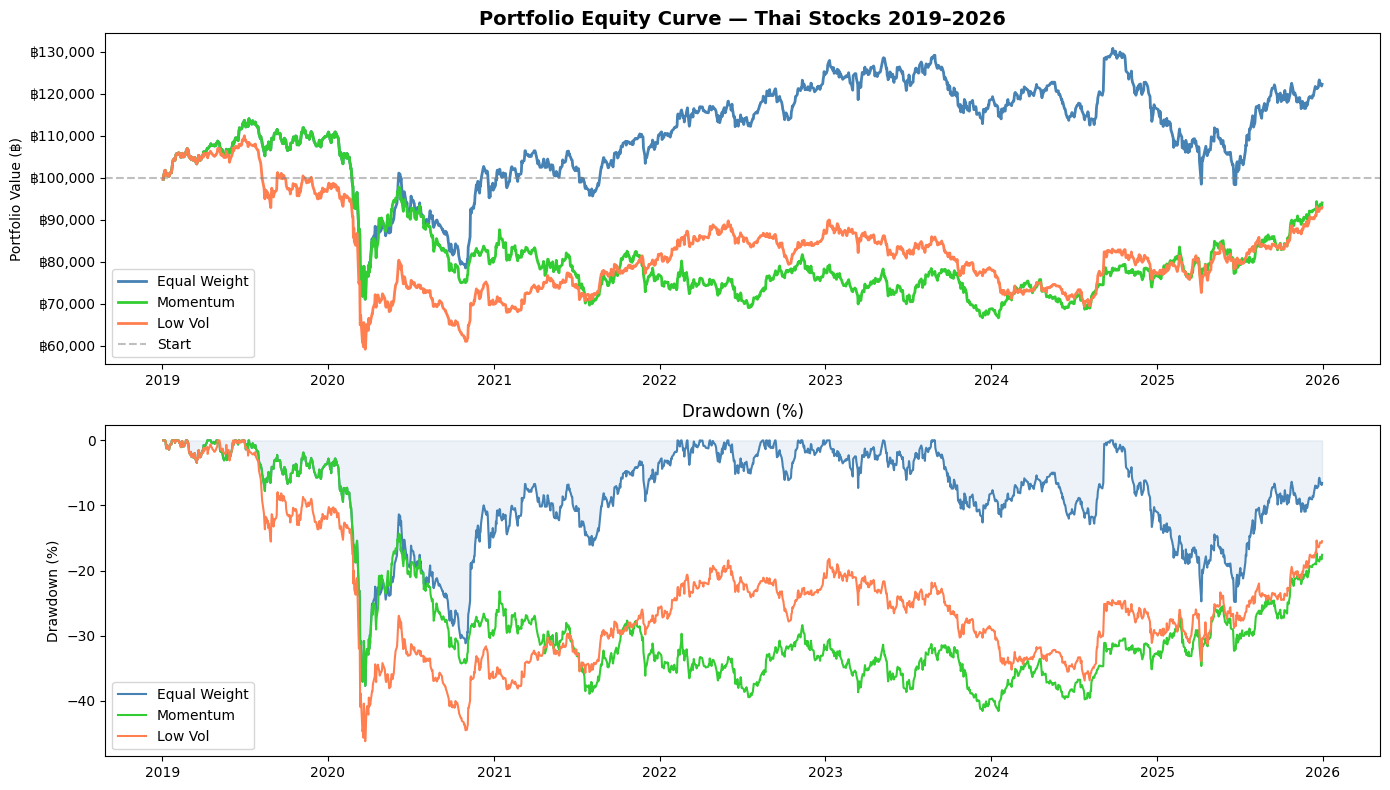

✅ บันทึกกราฟแล้ว


In [27]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Equity Curve
axes[0].plot(result_ew['Portfolio_Value'],
             label='Equal Weight', color='steelblue', linewidth=2)
axes[0].plot(result_mom['Portfolio_Value'],
             label='Momentum',     color='limegreen', linewidth=2)
axes[0].plot(result_lvol['Portfolio_Value'],
             label='Low Vol',      color='coral',     linewidth=2)
axes[0].axhline(y=100000, color='gray',
                linestyle='--', alpha=0.5, label='Start')
axes[0].set_title('Portfolio Equity Curve — Thai Stocks 2019–2026',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Portfolio Value (฿)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'฿{x:,.0f}'))

# Drawdown
for result, name, color in [
    (result_ew,   'Equal Weight', 'steelblue'),
    (result_mom,  'Momentum',     'limegreen'),
    (result_lvol, 'Low Vol',      'coral'),
]:
    roll_mx = result['Portfolio_Value'].cummax()
    dd      = (result['Portfolio_Value'] - roll_mx) / roll_mx * 100
    axes[1].plot(dd, label=name, color=color, linewidth=1.5)

axes[1].set_title('Drawdown (%)')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()
axes[1].fill_between(result_ew.index,
                     (result_ew['Portfolio_Value'].cummax() -
                      result_ew['Portfolio_Value']) /
                     result_ew['Portfolio_Value'].cummax() * -100,
                     0, alpha=0.1, color='steelblue')

plt.tight_layout()
plt.savefig('backtest_equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ บันทึกกราฟแล้ว")